In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mobil = pd.read_csv("automobileEDA_dirty_training.csv")
mobil.head()

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,01-03-2025,1,122,ALFA-ROMERO,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,04-Jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


In [3]:
mobil = mobil.rename(columns={'transaction_date': 'transaction-date'})
mobil.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction-date   203 non-null    str    
 1   symboling          205 non-null    int64  
 2   normalized-losses  205 non-null    int64  
 3   make               203 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       203 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [4]:
kolom_kategorik = mobil.select_dtypes(include=['object','category']).columns.tolist()
kolom_numerik = mobil.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(
    f"{kolom_numerik}, '\n'{kolom_kategorik}",
)

kolom_kategorik.remove('transaction-date')

['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price', 'city-L/100km', 'diesel', 'gas'], '
'['transaction-date', 'make', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system', 'horsepower-binned']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11120\3434139522.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kolom_kategorik = mobil.select_dtypes(include=['object','category']).columns.tolist()


In [5]:
mobil.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,205.000000,202.000000,205.000000,205.000000,205.000000,202.000000,205.000000,205.000000,205.000000
mean,0.839024,122.058537,98.784878,0.837107,0.915095,53.762927,2554.575610,126.980488,3.329020,3.258209,10.207902,103.403526,5119.515800,25.200000,30.721951,13181.668317,9.939602,0.102439,0.897561
std,1.247916,31.748344,6.018632,0.059030,0.028986,2.439080,515.016952,41.398466,0.266929,0.316354,4.064078,37.453870,476.073141,6.446917,6.836734,7924.054951,2.537799,0.303967,0.303967
min,-2.000000,65.000000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,101.000000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7778.250000,7.833333,0.000000,1.000000
50%,1.000000,122.000000,97.000000,0.832292,0.909722,54.100000,2420.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10320.000000,9.791667,0.000000,1.000000
75%,2.000000,137.000000,102.400000,0.881788,0.923611,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16482.500000,12.368421,0.000000,1.000000
max,3.000000,256.000000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


### Data Cleaning

#### Hapus Duplikat

In [6]:
print(mobil.duplicated().sum())
mobil = mobil.drop_duplicates()
print(mobil.duplicated().sum())

4
0


#### Handle Missing Value

In [7]:
print(mobil.isna().sum().sum())
print(mobil.isna().sum())

16
transaction-date     2
symboling            0
normalized-losses    0
make                 1
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               4
compression-ratio    0
horsepower           3
peak-rpm             0
city-mpg             0
highway-mpg          0
price                3
city-L/100km         0
horsepower-binned    1
diesel               0
gas                  0
dtype: int64


<Figure size 1000x1000 with 0 Axes>

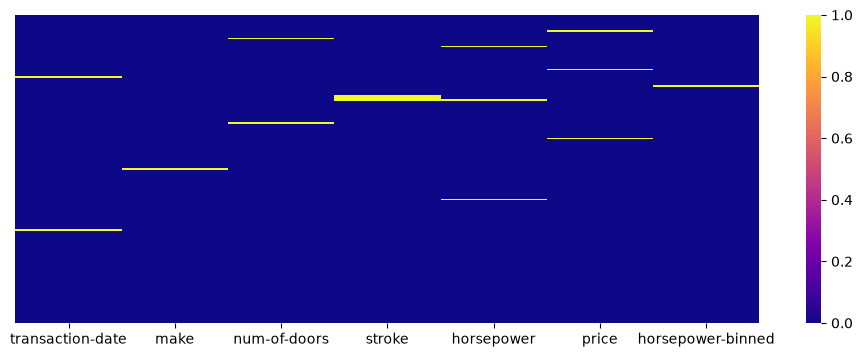

<Figure size 1000x1000 with 0 Axes>

In [8]:
missing_kolom = mobil.columns[mobil.isna().any()]
missing_df = mobil[missing_kolom]

plt.figure(figsize=(12, 4))
sns.heatmap(missing_df.isna(),
            cmap="plasma",
            cbar=True,
            yticklabels=False)
plt.figure(figsize=(10, 10))

In [9]:
mobil[mobil.isna().any(axis=1)]

,transaction-date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
10,01-11-2025,0,192,bmw,std,four,sedan,rwd,front,101.2,...,8.80,101.0,5800.0,23,29,NaN,10.217391,Low,0,1
15,16-Jan-2025,0,122,bmw,std,NaN,sedan,rwd,front,103.5,...,8.00,182.0,5400.0,16,22,41315.0,14.687500,High,0,1
20,2025-01-21,1,118,dodge,std,two,hatchback,fwd,front,93.7,...,9.41,NaN,5500.0,37,41,5572.0,6.351351,Low,0,1
35,05-Feb-2025,0,78,honda,std,four,wagon,fwd,front,96.5,...,9.20,76.0,6000.0,30,34,NaN,7.833333,Low,0,1
40,NaN,0,85,honda,std,four,sedan,fwd,front,96.5,...,9.00,101.0,5800.0,24,28,12945.0,9.791667,Low,0,1
46,02-16-2025,0,122,jaguar,std,two,sedan,rwd,front,102.0,...,11.50,262.0,5000.0,13,17,36000.0,18.076923,NaN,0,1
52,2025-02-22,3,150,mazda,std,two,hatchback,rwd,front,95.3,...,9.40,101.0,6000.0,17,23,10945.0,13.823529,Low,0,1
53,23/02/2025,3,150,mazda,std,two,hatchback,rwd,front,95.3,...,9.40,101.0,6000.0,17,23,11845.0,13.823529,Low,0,1
54,02-24-2025,3,150,mazda,std,two,hatchback,rwd,front,95.3,...,9.40,101.0,6000.0,17,23,13645.0,13.823529,Low,0,1
55,25-Feb-2025,3,150,mazda,std,two,hatchback,rwd,front,95.3,...,9.40,NaN,6000.0,16,23,15645.0,14.687500,Medium,0,1


In [10]:
mobil =  mobil.drop(columns=['transaction-date'])

##### Kategorik

In [11]:
mobil[kolom_kategorik].isna().sum()

make                 1
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
engine-type          0
num-of-cylinders     0
fuel-system          0
horsepower-binned    1
dtype: int64

In [12]:
mobil[kolom_kategorik] = mobil[kolom_kategorik].fillna('mode')
mobil[kolom_kategorik].isna().sum()

make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
engine-type          0
num-of-cylinders     0
fuel-system          0
horsepower-binned    0
dtype: int64

##### Numerik

In [13]:
print(mobil[kolom_numerik].isna().sum())

symboling            0
normalized-losses    0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-size          0
bore                 0
stroke               4
compression-ratio    0
horsepower           3
peak-rpm             0
city-mpg             0
highway-mpg          0
price                3
city-L/100km         0
diesel               0
gas                  0
dtype: int64


In [14]:
mobil[kolom_numerik] = mobil[kolom_numerik].fillna('mean')
print(mobil[kolom_numerik].isna().sum())

symboling            0
normalized-losses    0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-size          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
diesel               0
gas                  0
dtype: int64


In [15]:
print(mobil.isna().sum().sum())

0


#### Inconsistency

In [20]:
for kolom in kolom_kategorik:
    print(
        f"{'kolom'}: \n {mobil[kolom].unique()}, \n \n",
    )

kolom: 
 <StringArray>
[  'alfa-romero',   'ALFA-ROMERO',          'audi',           'bmw',
     'chevrolet',         'dodge',       'dodge  ',         'honda',
          'Audi',         'isuzu',        'jaguar',         'mazda',
 'mercedes-benz',     'mercury  ',    'mitsubishi',           'BMW',
        'nissan',          'mode',        'peugot',        'toyota',
      'plymouth',       'porsche',     'porsche  ',       'renault',
          'saab',        'subaru',    'volkswagen',         'volvo']
Length: 28, dtype: str, 
 

kolom: 
 <StringArray>
['std', 'turbo']
Length: 2, dtype: str, 
 

kolom: 
 <StringArray>
['two', 'four', 'mode']
Length: 3, dtype: str, 
 

kolom: 
 <StringArray>
['convertible', 'hatchback', 'sedan', 'wagon', 'SEDAN', 'Sedan', 'hardtop']
Length: 7, dtype: str, 
 

kolom: 
 <StringArray>
['rwd', 'fwd', '4wd', 'AWD', 'RWD']
Length: 5, dtype: str, 
 

kolom: 
 <StringArray>
['front', 'rear']
Length: 2, dtype: str, 
 

kolom: 
 <StringArray>
['dohc', 'ohcv', 'ohc'